In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error,r2_score


In [30]:

#Load dataset
housing = fetch_california_housing()
data = pd.DataFrame(housing.data, columns=housing.feature_names)
data["price"] = housing.target

#Select one feature
X=data[['AveRooms']].values
Y=data['price'].values


#Split data

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)



In [31]:


#Normal Equation

X_train_ne = np.c_[np.ones((len(X_train),1)),X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)),X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ Y_train



In [32]:
# Predictions
y_pred_ne = X_test_ne @ theta

# Parameters
b = theta[0]
w = theta[1]

# Results
print("Normal Equation")
print("-------------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(Y_test, y_pred_ne))
print("R2:", r2_score(Y_test, y_pred_ne))


Normal Equation
-------------------
Weight: 0.07675558963126736
Bias: 1.6547622685968417
MSE: 1.2923314440807299
R2: 0.013795337532284901


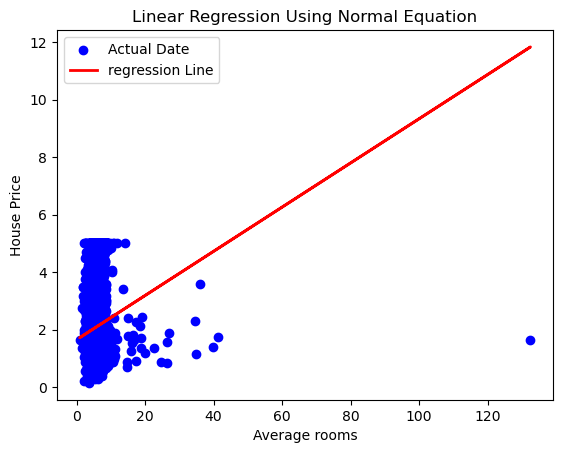

In [38]:
plt.scatter(X_test,Y_test,color="blue",label="Actual Date")
plt.plot(X_test,y_pred_ne,color="red",linewidth=2,label="regression Line")
plt.xlabel("Average rooms")
plt.ylabel("House Price")
plt.title("Linear Regression Using Normal Equation")
plt.legend()
plt.show()
           
           